In [1]:
# ALWAYS RUN THIS FIRST!
import os
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')


NOTEBOOK_DIR = Path("/rsrch9/home/plm/idso_fa1_pathology/codes/yshokrollahi/vitamin-p-latest")
os.chdir(NOTEBOOK_DIR)
sys.path.insert(0, str(NOTEBOOK_DIR))

print(f"✅ Working directory: {os.getcwd()}")

✅ Working directory: /rsrch9/home/plm/idso_fa1_pathology/codes/yshokrollahi/vitamin-p-latest


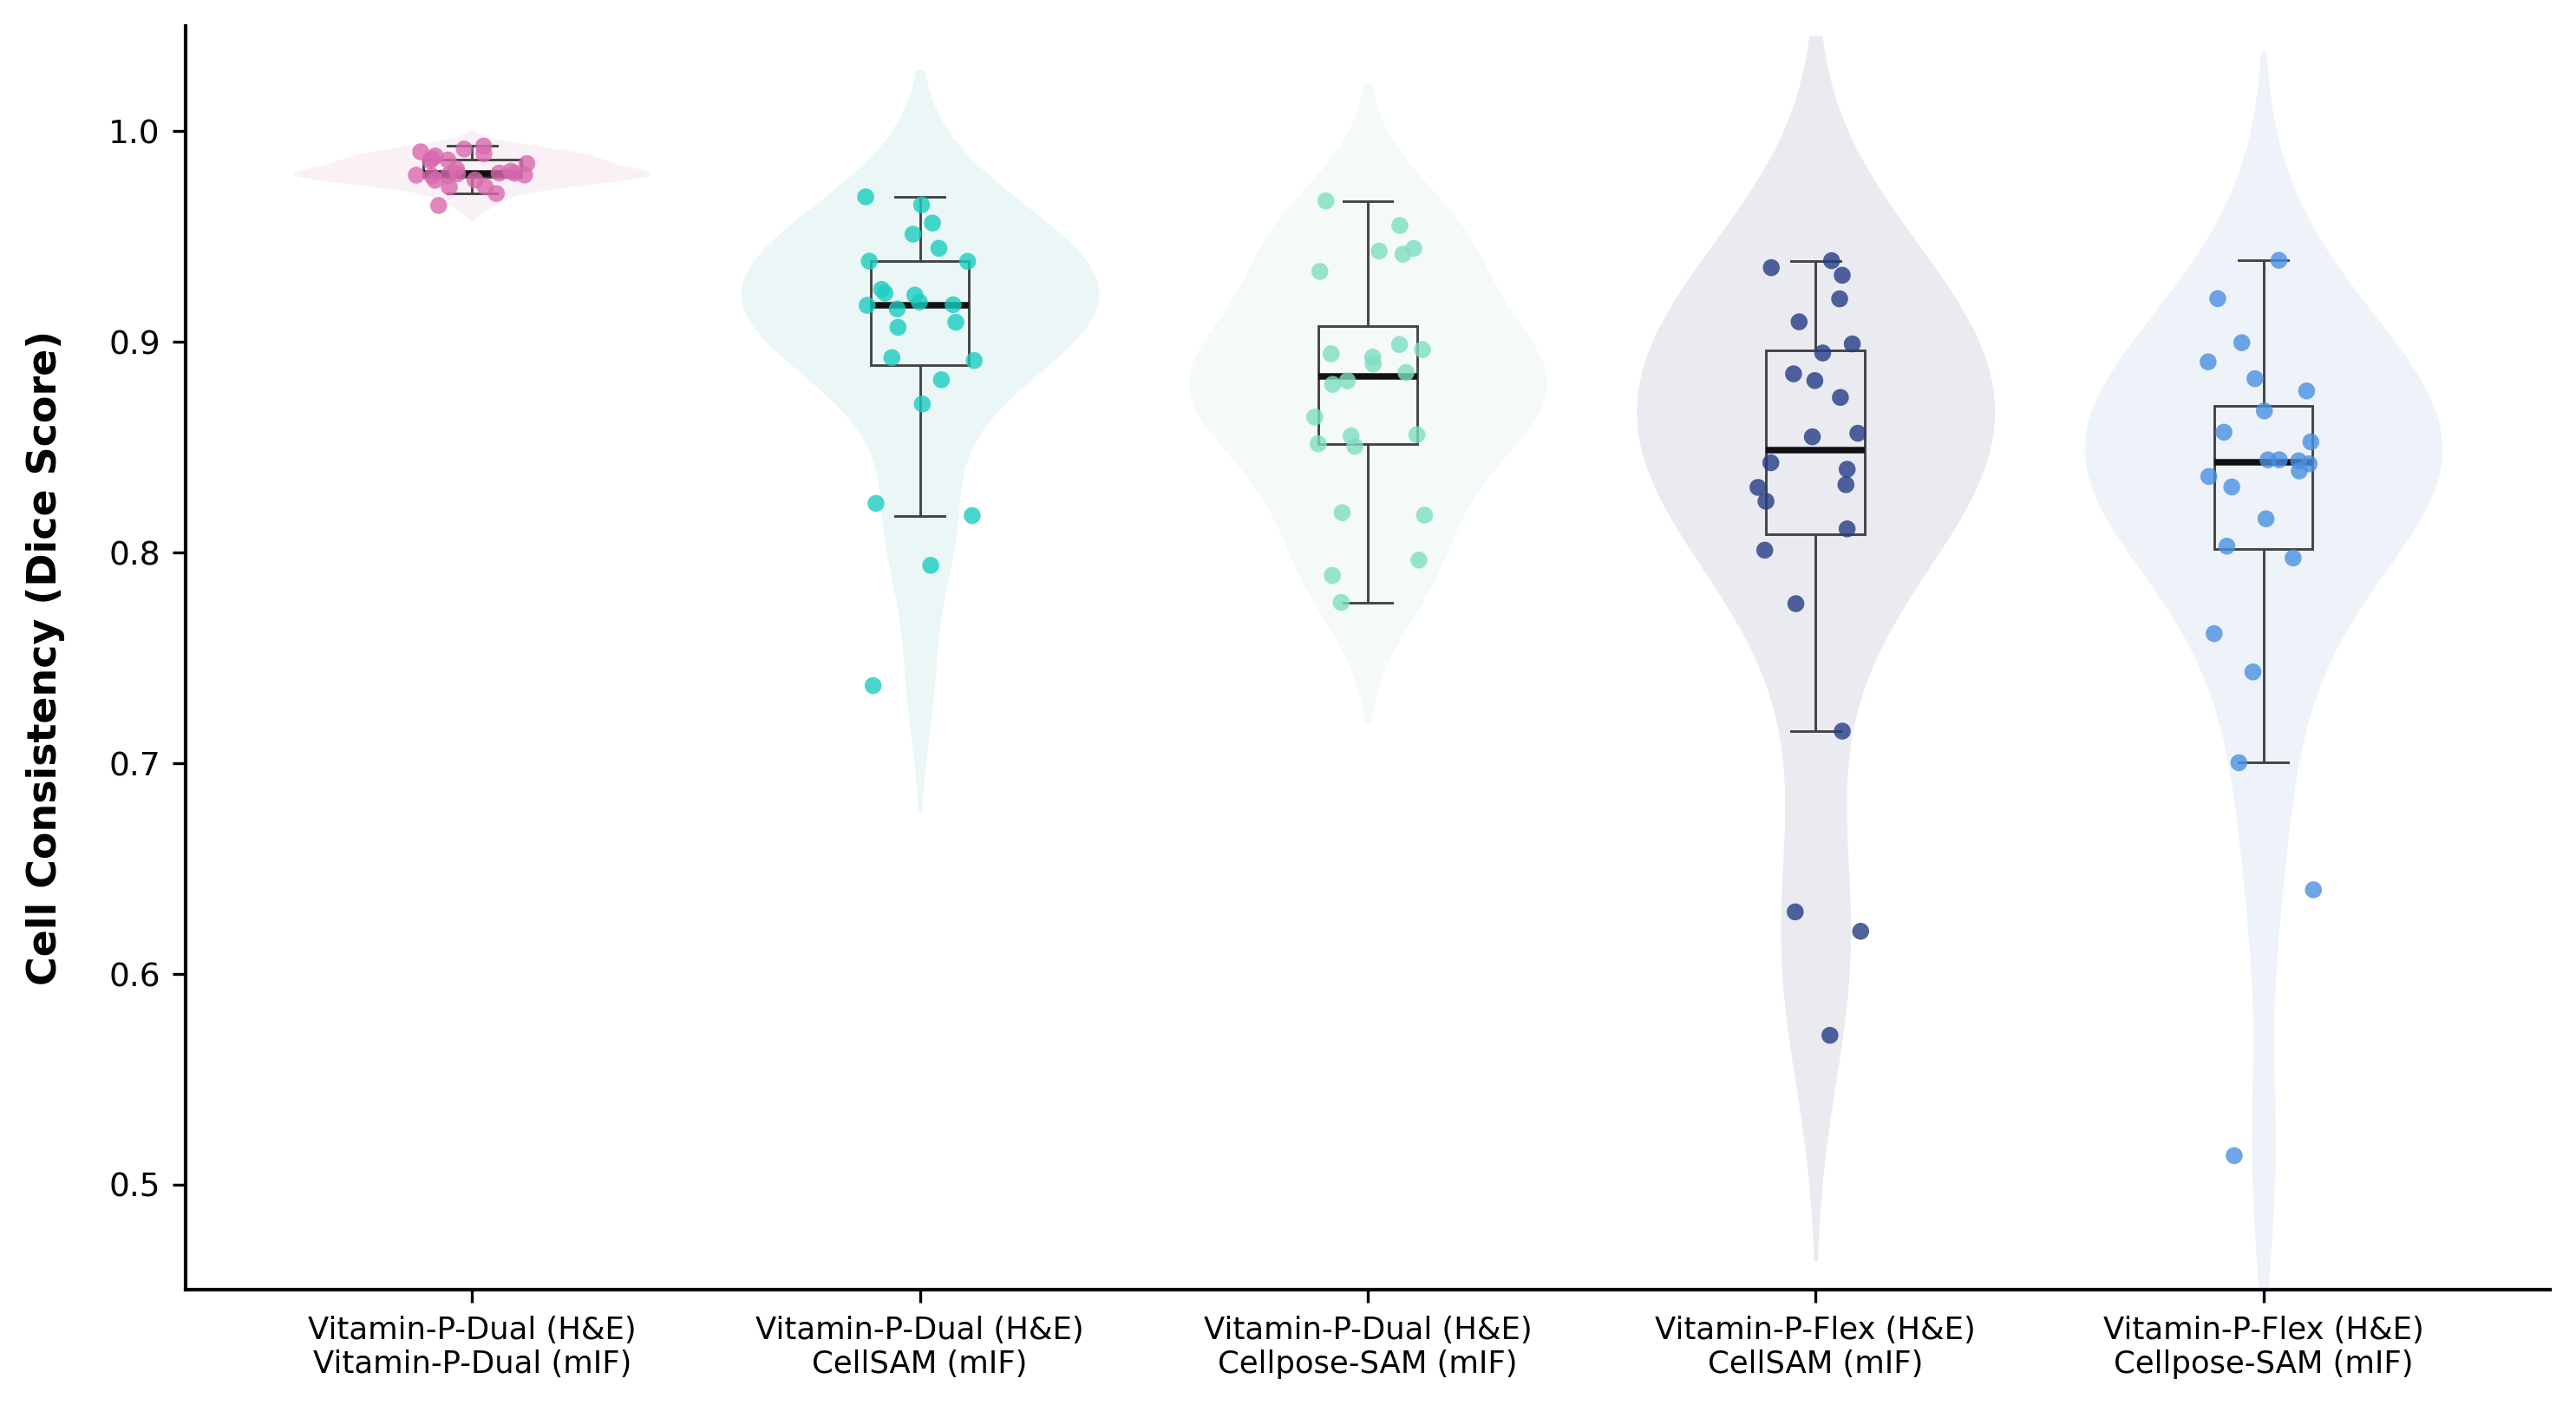

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- AI/Illustrator Compatibility ---
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Liberation Sans', 'Helvetica', 'Arial'],
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 1.0,
    'axes.labelsize': 10,
    'xtick.labelsize': 8.5,
    'ytick.labelsize': 9
})

# --- Final Model Order (Descending Performance) ---
order = [
    'Vitamin-P-Dual (H&E)\nVitamin-P-Dual (mIF)',
    'Vitamin-P-Dual (H&E)\nCellSAM (mIF)',
    'Vitamin-P-Dual (H&E)\nCellpose-SAM (mIF)',
    'Vitamin-P-Flex (H&E)\nCellSAM (mIF)', # Updated
    'Vitamin-P-Flex (H&E)\nCellpose-SAM (mIF)'
]

# --- ALL REAL DATA (Finalized) ---
data_dict = {
    order[0]: [0.9799, 0.9793, 0.9802, 0.9930, 0.9788, 0.9869, 0.9903, 0.9801, 0.9894, 0.9705, 0.9792, 0.9847, 0.9811, 0.9648, 0.9768, 0.9883, 0.9736, 0.9769, 0.9916, 0.9864, 0.9738, 0.9862, 0.9790, 0.9821],
    order[1]: [0.9223, 0.9177, 0.9232, 0.9651, 0.7940, 0.9174, 0.9565, 0.9250, 0.9384, 0.8176, 0.8912, 0.9094, 0.9157, 0.7369, 0.8821, 0.9512, 0.8234, 0.9190, 0.9689, 0.9383, 0.8926, 0.9445, 0.9070, 0.8706],
    order[2]: [0.8896, 0.8944, 0.8964, 0.9553, 0.7965, 0.9444, 0.9432, 0.8560, 0.9335, 0.7892, 0.8644, 0.8816, 0.8505, 0.7764, 0.8855, 0.8554, 0.8190, 0.8928, 0.9670, 0.9417, 0.8517, 0.8178, 0.8988, 0.8799],
    order[3]: [0.8310, 0.8991, 0.9205, 0.9317, 0.8396, 0.8244, 0.9096, 0.8427, 0.8567, 0.5709, 0.7758, 0.8012, 0.8849, 0.6295, 0.7153, 0.9386, 0.6203, 0.8550, 0.9353, 0.8737, 0.8323, 0.8948, 0.8113, 0.8817],
    order[4]: [0.8161, 0.8826, 0.8906, 0.9206, 0.8362, 0.8441, 0.8997, 0.8673, 0.8526, 0.5138, 0.7434, 0.7975, 0.8312, 0.7616, 0.7003, 0.8572, 0.6400, 0.8388, 0.9388, 0.8768, 0.8436, 0.8031, 0.8422, 0.8441]
}

df = pd.DataFrame([(m, s) for m, scores in data_dict.items() for s in scores], columns=['Model', 'dice'])

# --- Final Aesthetic Setup ---
fig, ax = plt.subplots(figsize=(10, 5.5), dpi=300)

# Colors: Magenta for Pure Dual, Teals for Dual-base, Blues for Flex-base
colors = {
    order[0]: '#d969ae', 
    order[1]: '#1bcdc0', 
    order[2]: '#7edec2', 
    order[3]: '#253c84', 
    order[4]: '#4a90e2'
}

# 1. Violin Plot
sns.violinplot(data=df, x='Model', y='dice', ax=ax, order=order, palette=colors, 
               hue='Model', legend=False, inner=None, alpha=0.1, linewidth=0, width=0.8)

# 2. Boxplot
sns.boxplot(data=df, x='Model', y='dice', ax=ax, order=order,
            boxprops={'facecolor': 'none', 'linewidth': 0.7, 'edgecolor': '#444444'},
            medianprops={'linewidth': 1.8, 'color': '#111111'},
            whiskerprops={'linewidth': 0.7, 'color': '#444444'},
            capprops={'linewidth': 0.7, 'color': '#444444'},
            flierprops={'marker': ''}, width=0.22)

# 3. Scatter Jitter
np.random.seed(42)
for i, model in enumerate(order):
    subset = df[df['Model'] == model]['dice'].values
    x_pos = i + np.random.uniform(-0.13, 0.13, size=len(subset))
    ax.scatter(x_pos, subset, color=colors[model], s=22, alpha=0.8, edgecolors='none', zorder=5)

# --- Final Labels ---
ax.set_ylabel('Cell Consistency (Dice Score)', fontweight='bold', fontsize=11, labelpad=12)
ax.set_xlabel('')
ax.set_ylim(0.45, 1.05) # Adjusted to show the spread better with new Flex-CellSAM data

plt.tight_layout()
plt.show()

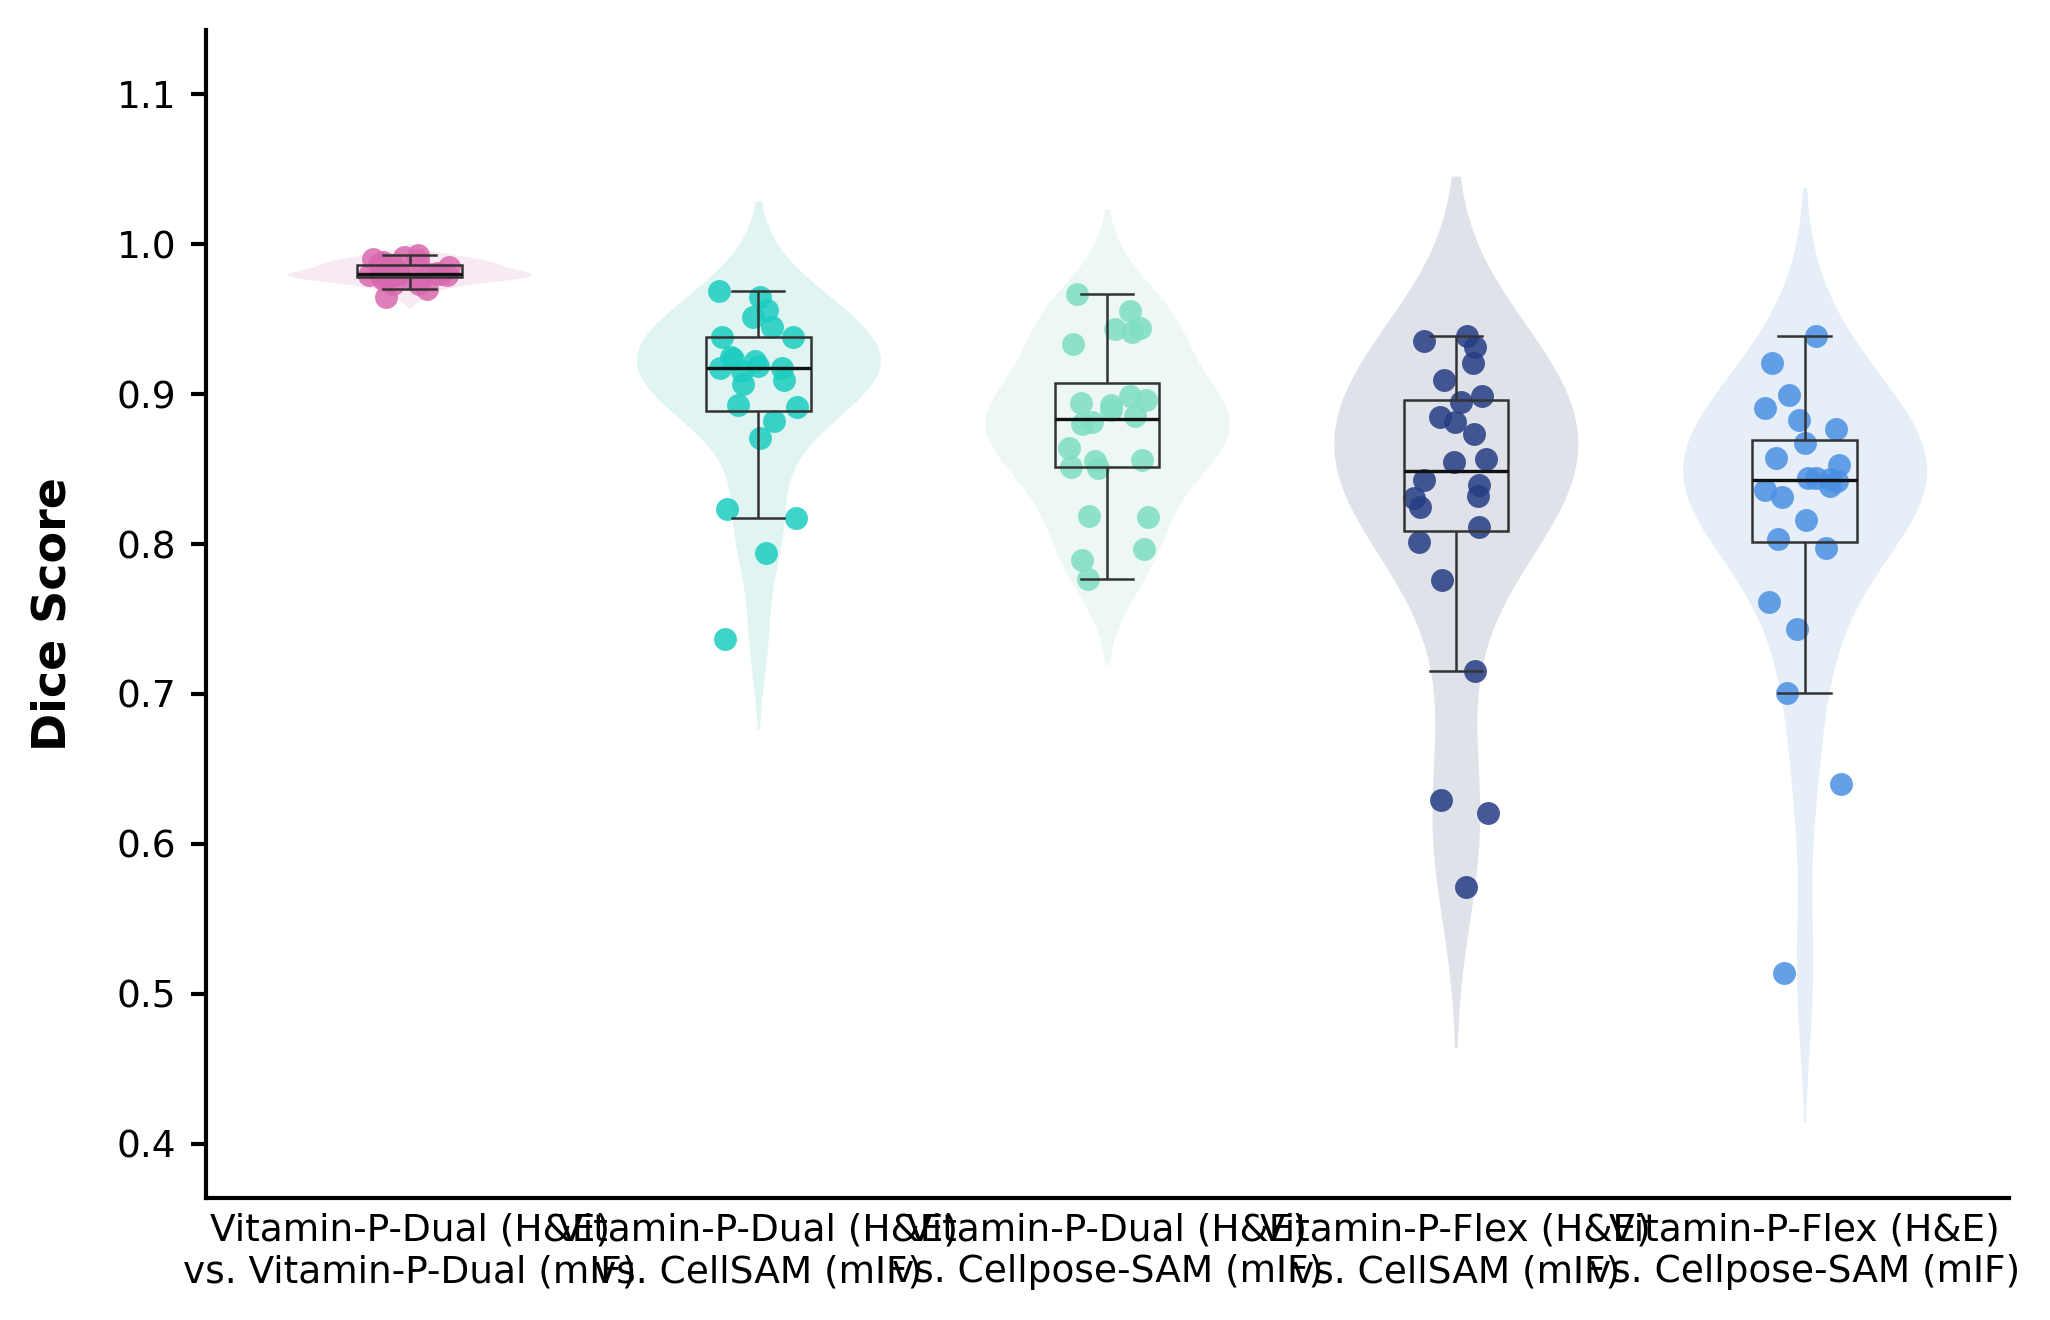

Saved.


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ---------------------------------------------------------
# SETTINGS FOR ADOBE ILLUSTRATOR COMPATIBILITY
# ---------------------------------------------------------
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['font.family'] = 'Arial'

# --- Data Definition ---
order = [
    'Vitamin-P-Dual (H&E)\nvs. Vitamin-P-Dual (mIF)',
    'Vitamin-P-Dual (H&E)\nvs. CellSAM (mIF)',
    'Vitamin-P-Dual (H&E)\nvs. Cellpose-SAM (mIF)',
    'Vitamin-P-Flex (H&E)\nvs. CellSAM (mIF)',
    'Vitamin-P-Flex (H&E)\nvs. Cellpose-SAM (mIF)'
]

data_dict = {
    order[0]: [0.9799, 0.9793, 0.9802, 0.9930, 0.9788, 0.9869, 0.9903, 0.9801, 0.9894, 0.9705,
               0.9792, 0.9847, 0.9811, 0.9648, 0.9768, 0.9883, 0.9736, 0.9769, 0.9916, 0.9864,
               0.9738, 0.9862, 0.9790, 0.9821],
    order[1]: [0.9223, 0.9177, 0.9232, 0.9651, 0.7940, 0.9174, 0.9565, 0.9250, 0.9384, 0.8176,
               0.8912, 0.9094, 0.9157, 0.7369, 0.8821, 0.9512, 0.8234, 0.9190, 0.9689, 0.9383,
               0.8926, 0.9445, 0.9070, 0.8706],
    order[2]: [0.8896, 0.8944, 0.8964, 0.9553, 0.7965, 0.9444, 0.9432, 0.8560, 0.9335, 0.7892,
               0.8644, 0.8816, 0.8505, 0.7764, 0.8855, 0.8554, 0.8190, 0.8928, 0.9670, 0.9417,
               0.8517, 0.8178, 0.8988, 0.8799],
    order[3]: [0.8310, 0.8991, 0.9205, 0.9317, 0.8396, 0.8244, 0.9096, 0.8427, 0.8567, 0.5709,
               0.7758, 0.8012, 0.8849, 0.6295, 0.7153, 0.9386, 0.6203, 0.8550, 0.9353, 0.8737,
               0.8323, 0.8948, 0.8113, 0.8817],
    order[4]: [0.8161, 0.8826, 0.8906, 0.9206, 0.8362, 0.8441, 0.8997, 0.8673, 0.8526, 0.5138,
               0.7434, 0.7975, 0.8312, 0.7616, 0.7003, 0.8572, 0.6400, 0.8388, 0.9388, 0.8768,
               0.8436, 0.8031, 0.8422, 0.8441]
}

df = pd.DataFrame([(m, s) for m, scores in data_dict.items() for s in scores],
                  columns=['Model', 'dice'])

# --- Plot Aesthetics (Nature Guidelines — consistent with ds_nuclei) ---
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 1.0,
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'pdf.fonttype': 42,
    'ps.fonttype': 42
})

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=300)

colors = {
    order[0]: '#d969ae',
    order[1]: '#1bcdc0',
    order[2]: '#7edec2',
    order[3]: '#253c84',
    order[4]: '#4a90e2'
}

# 1. Transparent Violin Plot
sns.violinplot(
    data=df, x='Model', y='dice', ax=ax,
    order=order, palette=colors, hue='Model', legend=False,
    inner=None, alpha=0.15, linewidth=0, width=0.7, zorder=1
)

# 2. Refined Boxplot Skeleton
sns.boxplot(
    data=df, x='Model', y='dice', ax=ax,
    order=order,
    boxprops={'facecolor': 'none', 'linewidth': 0.6, 'edgecolor': '#333333'},
    medianprops={'linewidth': 0.8, 'color': '#111111'},
    whiskerprops={'linewidth': 0.6, 'color': '#333333'},
    capprops={'linewidth': 0.6, 'color': '#333333'},
    flierprops={'marker': ''},
    width=0.3,
    zorder=10
)

# 3. Draw dots individually per point using ax.plot() so each dot is a
#    separate path object in the PDF → fully selectable in Adobe Illustrator.
np.random.seed(42)
jitter_strength = 0.12

for i, model in enumerate(order):
    subset = df[df['Model'] == model]['dice'].values
    color = colors[model]
    jitter = np.random.uniform(-jitter_strength, jitter_strength, size=len(subset))
    x_positions = i + jitter

    for x_pos, y_val in zip(x_positions, subset):
        ax.plot(
            x_pos, y_val,
            marker='o',
            markersize=5.5,
            color=color,
            alpha=0.85,
            markeredgewidth=0,
            linestyle='none',
            zorder=5
        )

# --- Labeling and Bounds ---
ax.set_ylabel('Dice Score', fontweight='bold', fontsize=11, labelpad=10)
ax.set_xlabel('')
ax.tick_params(axis='x', length=0)
plt.xticks(fontweight='medium')

min_val = df['dice'].min()
max_val = df['dice'].max()
ax.set_ylim(min_val - 0.15, max_val + 0.15)

plt.tight_layout()
plt.savefig('ds_crossmodal.pdf', format='pdf', bbox_inches='tight', transparent=True)
plt.show()
print("Saved.")

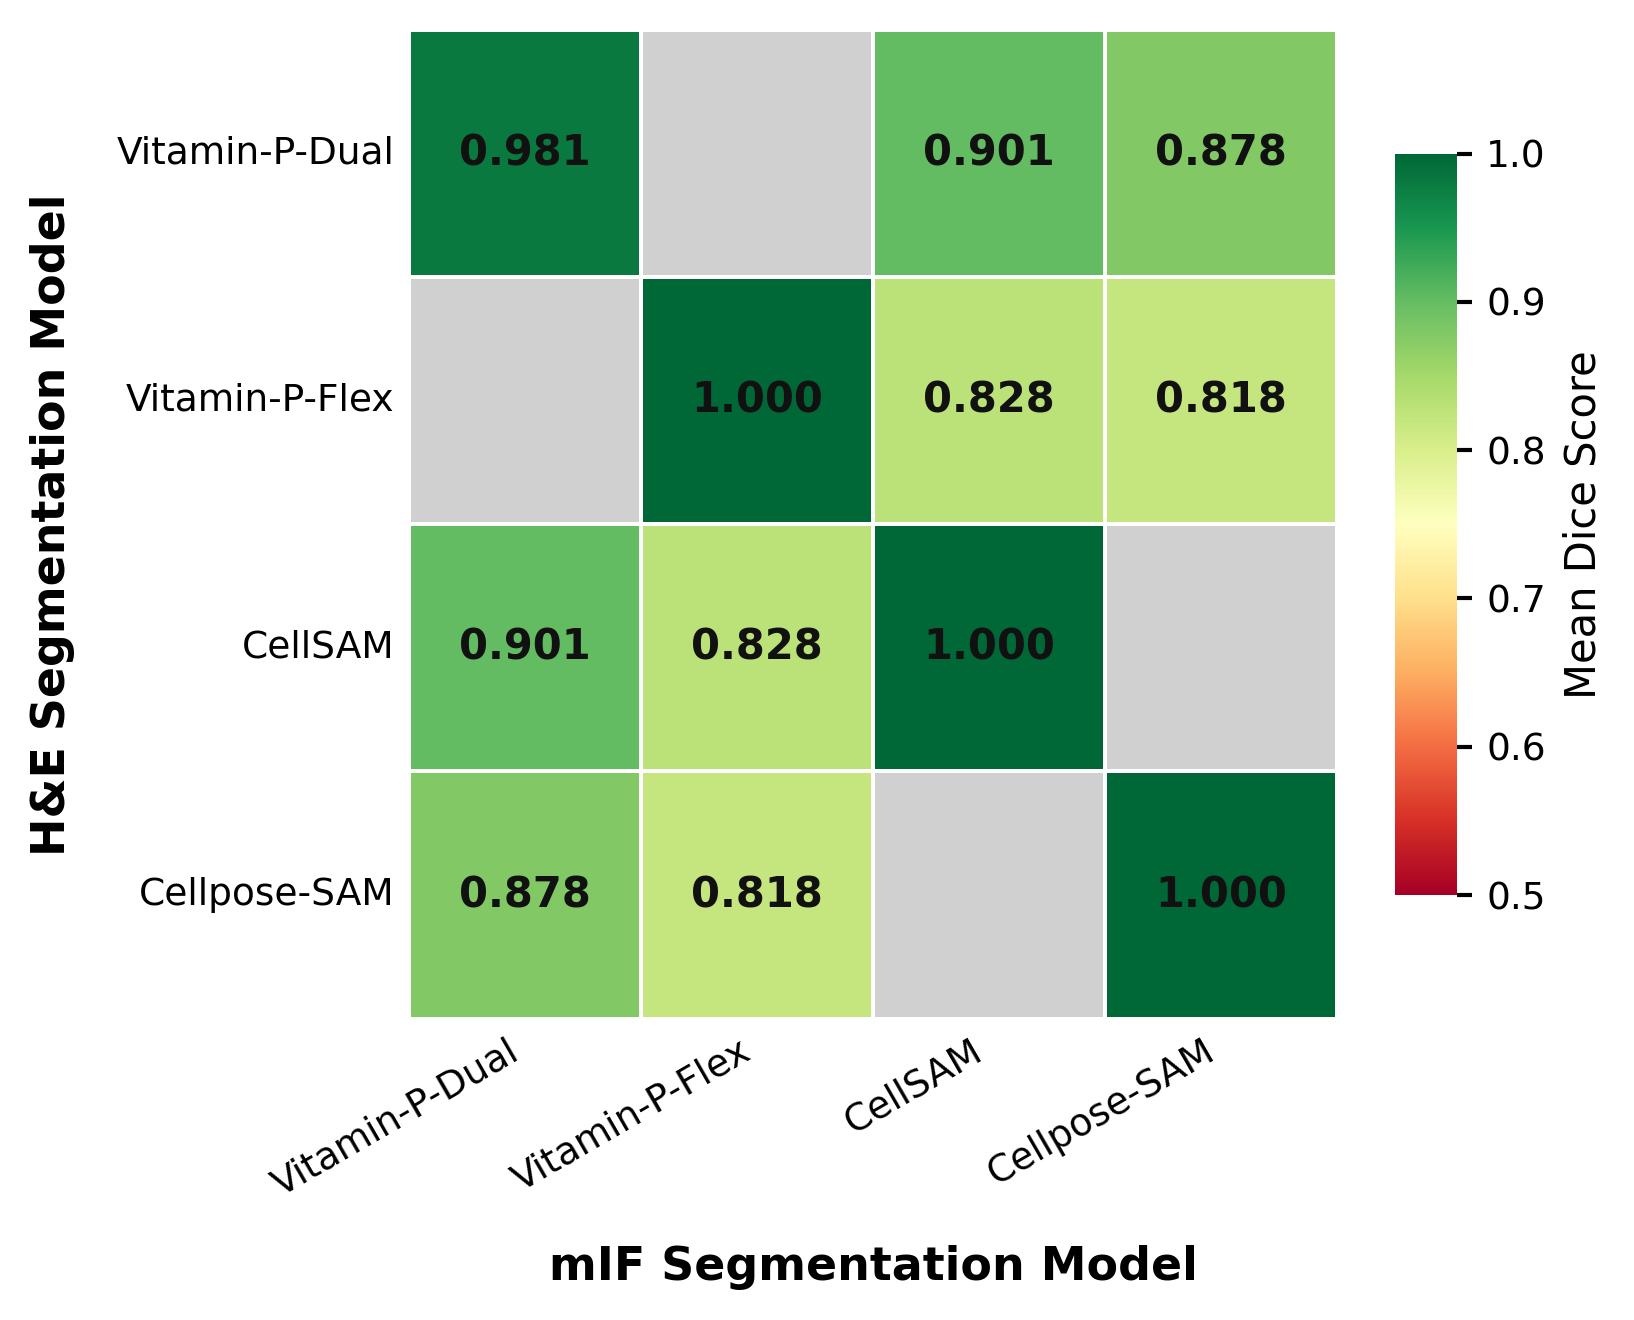

Saved.


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'pdf.fonttype': 42, 'ps.fonttype': 42,
    'axes.linewidth': 1.0,
    'axes.labelsize': 10, 'xtick.labelsize': 9, 'ytick.labelsize': 9
})

# --- Data ---
order = [
    'Vitamin-P-Dual (H&E)\nvs. Vitamin-P-Dual (mIF)',
    'Vitamin-P-Dual (H&E)\nvs. CellSAM (mIF)',
    'Vitamin-P-Dual (H&E)\nvs. Cellpose-SAM (mIF)',
    'Vitamin-P-Flex (H&E)\nvs. CellSAM (mIF)',
    'Vitamin-P-Flex (H&E)\nvs. Cellpose-SAM (mIF)'
]

data_dict = {
    order[0]: [0.9799, 0.9793, 0.9802, 0.9930, 0.9788, 0.9869, 0.9903, 0.9801, 0.9894, 0.9705,
               0.9792, 0.9847, 0.9811, 0.9648, 0.9768, 0.9883, 0.9736, 0.9769, 0.9916, 0.9864,
               0.9738, 0.9862, 0.9790, 0.9821],
    order[1]: [0.9223, 0.9177, 0.9232, 0.9651, 0.7940, 0.9174, 0.9565, 0.9250, 0.9384, 0.8176,
               0.8912, 0.9094, 0.9157, 0.7369, 0.8821, 0.9512, 0.8234, 0.9190, 0.9689, 0.9383,
               0.8926, 0.9445, 0.9070, 0.8706],
    order[2]: [0.8896, 0.8944, 0.8964, 0.9553, 0.7965, 0.9444, 0.9432, 0.8560, 0.9335, 0.7892,
               0.8644, 0.8816, 0.8505, 0.7764, 0.8855, 0.8554, 0.8190, 0.8928, 0.9670, 0.9417,
               0.8517, 0.8178, 0.8988, 0.8799],
    order[3]: [0.8310, 0.8991, 0.9205, 0.9317, 0.8396, 0.8244, 0.9096, 0.8427, 0.8567, 0.5709,
               0.7758, 0.8012, 0.8849, 0.6295, 0.7153, 0.9386, 0.6203, 0.8550, 0.9353, 0.8737,
               0.8323, 0.8948, 0.8113, 0.8817],
    order[4]: [0.8161, 0.8826, 0.8906, 0.9206, 0.8362, 0.8441, 0.8997, 0.8673, 0.8526, 0.5138,
               0.7434, 0.7975, 0.8312, 0.7616, 0.7003, 0.8572, 0.6400, 0.8388, 0.9388, 0.8768,
               0.8436, 0.8031, 0.8422, 0.8441]
}

means = {model: np.mean(scores) for model, scores in data_dict.items()}

# --- Short labels ---
row_labels = ['Vitamin-P-Dual', 'Vitamin-P-Flex']   # H&E models (rows)
col_labels = ['Vitamin-P-Dual', 'CellSAM', 'Cellpose-SAM']  # mIF models (cols)

# --- Build 4x4 unified matrix with all unique model names ---
all_labels = ['Vitamin-P-Dual', 'Vitamin-P-Flex', 'CellSAM', 'Cellpose-SAM']
n = len(all_labels)

matrix = np.full((n, n), np.nan)  # NaN = grey

# Diagonal = 1.0
for i in range(n):
    matrix[i, i] = 1.0

# Map comparisons to (row_idx, col_idx) in the unified label space
# Rows = H&E model, Cols = mIF model
comparison_map = {
    ('Vitamin-P-Dual', 'Vitamin-P-Dual'): means[order[0]],
    ('Vitamin-P-Dual', 'CellSAM'):         means[order[1]],
    ('Vitamin-P-Dual', 'Cellpose-SAM'):    means[order[2]],
    ('Vitamin-P-Flex', 'CellSAM'):         means[order[3]],
    ('Vitamin-P-Flex', 'Cellpose-SAM'):    means[order[4]],
}

idx = {label: i for i, label in enumerate(all_labels)}

for (r, c), val in comparison_map.items():
    ri, ci = idx[r], idx[c]
    matrix[ri, ci] = val
    matrix[ci, ri] = val  # mirror

# --- Mask for grey (NaN) cells ---
mask = np.isnan(matrix)

# --- Plot ---
fig, ax = plt.subplots(figsize=(5.5, 4.5), dpi=300)

# Grey background for masked cells
ax.set_facecolor('#e8e8e8')

sns.heatmap(
    matrix, ax=ax,
    mask=mask,
    cmap='RdYlGn', vmin=0.5, vmax=1.0,
    annot=True, fmt='.3f',
    annot_kws={'size': 10, 'fontweight': 'bold', 'color': '#111111'},
    linewidths=0.5, linecolor='white',
    xticklabels=all_labels,
    yticklabels=all_labels,
    cbar_kws={'label': 'Mean Dice Score', 'shrink': 0.75, 'aspect': 12}
)

# Fill masked cells explicitly with grey
for i in range(n):
    for j in range(n):
        if mask[i, j]:
            ax.add_patch(mpatches.Rectangle(
                (j, i), 1, 1,
                color='#d0d0d0', zorder=0
            ))

ax.set_xlabel('mIF Segmentation Model', fontweight='bold', fontsize=11, labelpad=10)
ax.set_ylabel('H&E Segmentation Model', fontweight='bold', fontsize=11, labelpad=10)
ax.tick_params(axis='both', length=0)
plt.xticks(rotation=30, ha='right', fontweight='medium', fontsize=9)
plt.yticks(rotation=0, fontweight='medium', fontsize=9)

plt.tight_layout()
plt.savefig('ds_crossmodal_matrix.pdf', format='pdf', bbox_inches='tight', transparent=True)
plt.show()
print("Saved.")